# Titanic 2 — 딥러닝 이진 분류 실습

**데이터**: `pandas/data/titanic2.csv` (1,309건)
**목표**: 생존 여부(`2urvived`) 예측 — **이진 분류(Binary Classification)**

## 학습 흐름
1. 데이터 탐색적 분석 (EDA)
2. 시각화 분석
3. 데이터 전처리
4. 데이터 분할 & 스케일링
5. Baseline 딥러닝 모델
6. 모델 평가
7. 모델 개선
8. 개선 결과 비교
9. sklearn 모델과 비교

## 데이터 특징
- 기존 Titanic 데이터(891건)보다 **행이 더 많음** (1,309건 = train+test 합본 추정)
- **라벨 인코딩이 이미 적용**되어 있음 (Sex: 0/1, Embarked: 0/1/2)
- 컬럼명에 오타 존재: `2urvived` (Survived)

## 컬럼 설명

| 컬럼 | 설명 | 값 |
|------|------|----|
| Passengerid | 승객 ID (제거 대상) | 1~1309 |
| Age | 나이 | 0.17~80 |
| Fare | 운임 | 0~512 |
| Sex | 성별 (라벨 인코딩) | 0=남성, 1=여성 |
| sibsp | 동반 형제/배우자 수 | 0~8 |
| Pclass | 좌석 등급 | 1=1등석, 2=2등석, 3=3등석 |
| Embarked | 탑승항구 (라벨 인코딩) | 0=C, 1=Q, 2=S (추정) |
| **2urvived** | **생존 여부 (타겟)** | **0=사망, 1=생존** |

## 1. 데이터 탐색적 분석 (EDA)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

df = pd.read_csv('pandas/data/titanic2.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1309, 8)


,Passengerid,Age,Fare,Sex,sibsp,Pclass,Embarked,2urvived
0,1,22.0,7.2500,0,1,3,2.0,0
1,2,38.0,71.2833,1,1,1,0.0,1
2,3,26.0,7.9250,1,0,3,2.0,1
3,4,35.0,53.1000,1,1,1,2.0,1
4,5,35.0,8.0500,0,0,3,2.0,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Pclass       1309 non-null   int64  
 6   Embarked     1307 non-null   float64
 7   2urvived     1309 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 81.9 KB


In [27]:
df.describe()

,Passengerid,Age,Fare,Sex,sibsp,Pclass,Embarked,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1307.000000,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,2.294882,1.492731,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.837836,0.814626,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,2.000000,1.000000,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,3.000000,2.000000,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,3.000000,2.000000,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,3.000000,2.000000,1.000000


In [28]:
# 결측치 확인
print('=== 결측치 ===')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else '결측치 없음')

print('\n=== 각 컬럼 고유값 ===')
for col in df.columns:
  print(f'  {col:15s}: {df[col].nunique():>5d}개  → {sorted(df[col].dropna().unique())[:6]}')

=== 결측치 ===
Embarked    2
dtype: int64

=== 각 컬럼 고유값 ===
  Passengerid    :  1309개  → [1, 2, 3, 4, 5, 6]
  Age            :    98개  → [0.17, 0.33, 0.42, 0.67, 0.75, 0.83]
  Fare           :   281개  → [0.0, 3.1708, 4.0125, 5.0, 6.2375, 6.4375]
  Sex            :     2개  → [0, 1]
  sibsp          :     7개  → [0, 1, 2, 3, 4, 5]
  Pclass         :     3개  → [1, 2, 3]
  Embarked       :     3개  → [0.0, 1.0, 2.0]
  2urvived       :     2개  → [0, 1]


In [29]:
# 타겟 분포
print('=== 생존 여부 분포 ===')
print(df['2urvived'].value_counts())
print(f'\n생존률: {df["2urvived"].mean():.4f} ({df["2urvived"].mean()*100:.1f}%)')
print(f'→ 클래스 불균형: 사망 {(1 - df["2urvived"].mean())*100:.0f}% vs 생존 {df["2urvived"].mean()*100:.0f}%')

=== 생존 여부 분포 ===
2urvived
0    967
1    342
Name: count, dtype: int64

생존률: 0.2613 (26.1%)
→ 클래스 불균형: 사망 74% vs 생존 26%


## 2. 시각화 분석

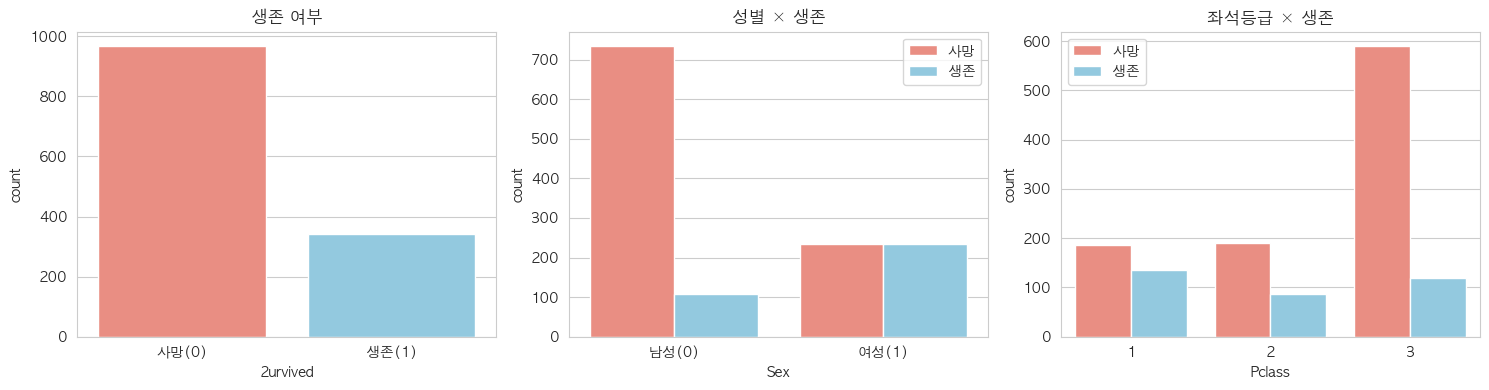

→ 여성, 1등석일수록 생존율 높음


In [30]:
# 1) 타겟 분포 + 성별 생존율
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='2urvived', ax=axes[0], palette=['salmon', 'skyblue'])
axes[0].set_title('생존 여부')
axes[0].set_xticklabels(['사망(0)', '생존(1)'])

sns.countplot(data=df, x='Sex', hue='2urvived', ax=axes[1], palette=['salmon', 'skyblue'])
axes[1].set_title('성별 × 생존')
axes[1].set_xticklabels(['남성(0)', '여성(1)'])
axes[1].legend(['사망', '생존'])

sns.countplot(data=df, x='Pclass', hue='2urvived', ax=axes[2], palette=['salmon', 'skyblue'])
axes[2].set_title('좌석등급 × 생존')
axes[2].legend(['사망', '생존'])

plt.tight_layout()
plt.show()
print('→ 여성, 1등석일수록 생존율 높음')

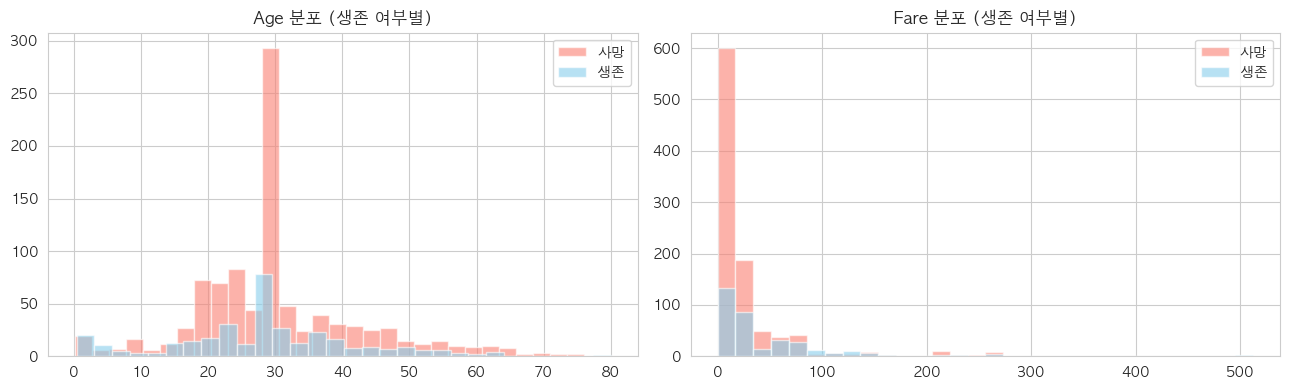

In [31]:
# 2) 연속형 변수 분포 (생존 여부별)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for surv, color, label in [(0, 'salmon', '사망'), (1, 'skyblue', '생존')]:
  axes[0].hist(df[df['2urvived'] == surv]['Age'], bins=30, alpha=0.6,
               color=color, label=label, edgecolor='white')
  axes[1].hist(df[df['2urvived'] == surv]['Fare'], bins=30, alpha=0.6,
               color=color, label=label, edgecolor='white')

axes[0].set_title('Age 분포 (생존 여부별)')
axes[0].legend()
axes[1].set_title('Fare 분포 (생존 여부별)')
axes[1].legend()

plt.tight_layout()
plt.show()

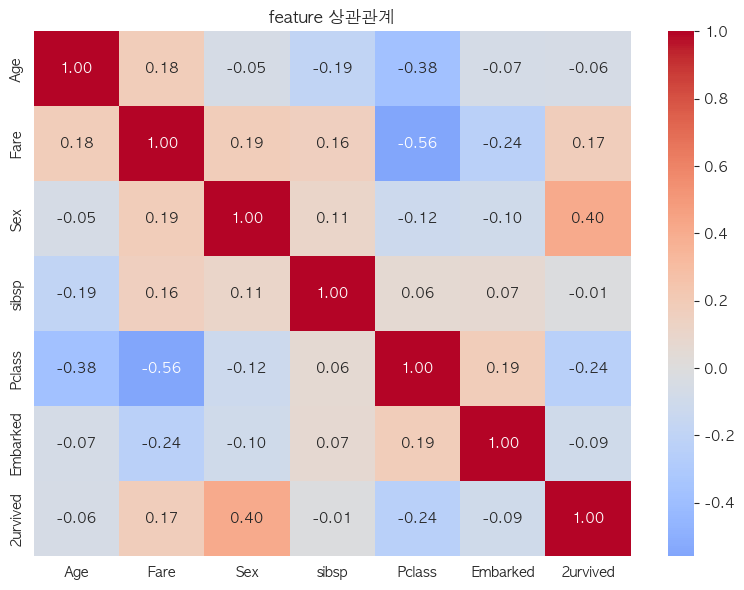

→ Sex, Pclass, Fare가 2urvived와 상관관계 높음


In [32]:
# 3) 상관관계 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns='Passengerid').corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('feature 상관관계')
plt.tight_layout()
plt.show()
print('→ Sex, Pclass, Fare가 2urvived와 상관관계 높음')

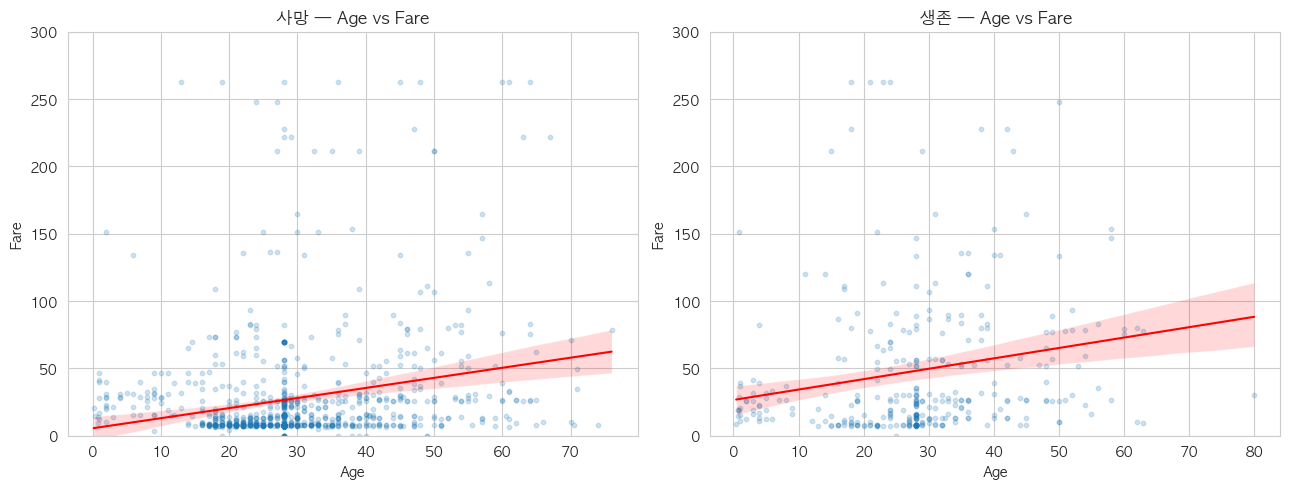

→ 생존자가 전반적으로 Fare가 높은 경향


In [33]:
# 4) Fare vs Age — regplot (생존 여부별)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, surv, title in zip(axes, [0, 1], ['사망', '생존']):
  subset = df[df['2urvived'] == surv]
  sns.regplot(data=subset, x='Age', y='Fare', ax=ax,
              scatter_kws={'alpha': 0.2, 's': 10},
              line_kws={'color': 'red', 'lw': 1.5})
  ax.set_title(f'{title} — Age vs Fare')
  ax.set_ylim(0, 300)

plt.tight_layout()
plt.show()
print('→ 생존자가 전반적으로 Fare가 높은 경향')

## 3. 데이터 전처리

### 처리 내용
- **제거**: `Passengerid` — ID는 학습에 불필요
- **결측치**: `Embarked` 2건 → 최빈값으로 대체
- **라벨 인코딩 이미 적용됨** — Sex(0/1), Embarked(0/1/2) → 추가 인코딩 불필요
- `Pclass`, `Embarked`는 순서가 의미 있는 수치이므로 그대로 사용

In [34]:
df_p = df.copy()

# Passengerid 제거
df_p = df_p.drop(columns='Passengerid')

# Embarked 결측치 → 최빈값 대체
embarked_mode = df_p['Embarked'].mode()[0]
df_p['Embarked'] = df_p['Embarked'].fillna(embarked_mode)
print(f'Embarked 최빈값: {embarked_mode}')

print(f'\n전처리 후 shape: {df_p.shape}')
print(f'결측치: {df_p.isnull().sum().sum()}')
df_p.head()

Embarked 최빈값: 2.0

전처리 후 shape: (1309, 7)
결측치: 0


,Age,Fare,Sex,sibsp,Pclass,Embarked,2urvived
0,22.0,7.2500,0,1,3,2.0,0
1,38.0,71.2833,1,1,1,0.0,1
2,26.0,7.9250,1,0,3,2.0,1
3,35.0,53.1000,1,1,1,2.0,1
4,35.0,8.0500,0,0,3,2.0,0


## 4. 데이터 분할 & 스케일링

### 분류에서 y 스케일링이 불필요한 이유
| | 회귀 | 분류 |
|---|---|---|
| y 값 | 연속값 (수백~수만) | **라벨 0/1** |
| 출력층 | linear (제한 없음) | **sigmoid (이미 0~1)** |
| Loss | MSE — y²이 gradient에 반영 → 폭발 위험 | **BCE — 0/1이라 안정적** |
| y 스케일링 | **필요** | **불필요** |

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_p.drop('2urvived', axis=1)
y = df_p['2urvived']

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

# X만 스케일링 (y는 0/1이므로 불필요)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'X_train: {X_train_s.shape}, X_test: {X_test_s.shape}')
print(f'y_train 분포:\n{y_train.value_counts()}')
print(f'\ny_test 분포:\n{y_test.value_counts()}')

X_train: (1047, 6), X_test: (262, 6)
y_train 분포:
2urvived
0    773
1    274
Name: count, dtype: int64

y_test 분포:
2urvived
0    194
1     68
Name: count, dtype: int64


## 5. Baseline 딥러닝 모델
- 구조: Dense 32 → 16 → 1(sigmoid)
- loss: `binary_crossentropy`
- 이진 분류: 출력층 `sigmoid` + `binary_crossentropy` 조합

In [36]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

tf.random.set_seed(42)
np.random.seed(42)

input_dim = X_train_s.shape[1]

baseline = Sequential([
  layers.Dense(32, activation='relu', input_shape=(input_dim,)),
  layers.Dense(16, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

baseline.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)
baseline.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 32)                224       
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dense_8 (Dense)             (None, 1)                 17        
                                                                 
Total params: 769 (3.00 KB)
Trainable params: 769 (3.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [37]:
history_base = baseline.fit(
  X_train_s, y_train,
  validation_split=0.2,
  epochs=100,
  batch_size=32,
  verbose=0
)
print(f'학습 완료 (epoch={len(history_base.history["loss"])})')

학습 완료 (epoch=100)


## 6. 모델 평가 (Baseline)
- 지표: Accuracy, Precision, Recall, F1, AUC
- 혼동 행렬

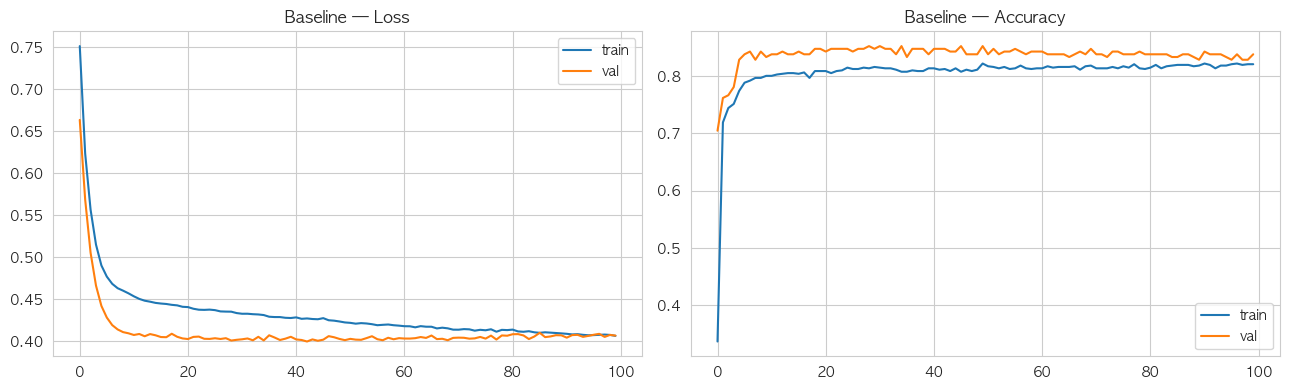

In [38]:
# 학습 곡선
def plot_history(history, title='Learning Curve'):
  fig, axes = plt.subplots(1, 2, figsize=(13, 4))
  axes[0].plot(history.history['loss'], label='train')
  axes[0].plot(history.history['val_loss'], label='val')
  axes[0].set_title(f'{title} — Loss')
  axes[0].legend()
  axes[1].plot(history.history['accuracy'], label='train')
  axes[1].plot(history.history['val_accuracy'], label='val')
  axes[1].set_title(f'{title} — Accuracy')
  axes[1].legend()
  plt.tight_layout()
  plt.show()

plot_history(history_base, 'Baseline')

### 분류 평가 지표 — Accuracy, Precision, Recall, F1, AUC

평가 지표를 이해하려면 먼저 **혼동 행렬(Confusion Matrix)**을 알아야 합니다.

---

#### 혼동 행렬 (Confusion Matrix)

타이타닉 생존 예측의 경우 (양성=생존, 음성=사망):

```
                    예측: 사망      예측: 생존
실제: 사망        TN (참 음성)    FP (거짓 양성)
                  사망→사망 ✓     사망→생존 ✗

실제: 생존        FN (거짓 음성)  TP (참 양성)
                  생존→사망 ✗     생존→생존 ✓
```

- **TP** (True Positive): 생존자를 생존이라 맞춤
- **TN** (True Negative): 사망자를 사망이라 맞춤
- **FP** (False Positive): 사망자를 생존이라 틀림 (오탐)
- **FN** (False Negative): 생존자를 사망이라 틀림 (미탐)

---

#### 1. Accuracy (정확도)

**전체 중 맞춘 비율**

```
Accuracy = (TP + TN) / (TP + TN + FP + FN)
```

직관: 100명 중 80명을 맞췄다 → Accuracy = 0.80

**함정**: 타이타닉 사망 74%, 생존 26%에서 "전부 사망" 예측 → Accuracy = **74%**
생존자를 한 명도 못 찾았는데 높은 점수! → **불균형 데이터에서는 Accuracy만 보면 안 됨**

---

#### 2. Precision (정밀도)

**"생존이라 예측한 것 중" 진짜 생존자 비율**

```
Precision = TP / (TP + FP)
```

직관: 모델이 "이 사람 생존!" 이라고 50명을 찍었는데, 그 중 40명이 진짜 생존 → Precision = 0.80

**Precision이 중요한 경우**: 스팸 메일 필터
- "스팸입니다" 라고 판단한 메일 중 정상 메일이 있으면 큰 문제 (중요 메일 삭제)
- FP(정상→스팸)를 줄이는 게 핵심 → **Precision을 높여야 함**

---

#### 3. Recall (재현율, 민감도)

**"실제 생존자 중" 모델이 찾아낸 비율**

```
Recall = TP / (TP + FN)
```

직관: 실제 생존자 68명 중 모델이 50명을 찾아냄 → Recall = 0.74 (18명 놓침)

**Recall이 중요한 경우**: 암 진단
- 실제 암 환자를 "정상"이라 하면 치명적 (치료 기회 놓침)
- FN(암→정상)을 줄이는 게 핵심 → **Recall을 높여야 함**

---

#### 4. F1 Score

**Precision과 Recall의 조화 평균**

```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```

**왜 단순 평균이 아닌 조화 평균인가?**

| | Precision | Recall | 단순 평균 | 조화 평균(F1) |
|---|---|---|---|---|
| 모델A | 0.90 | 0.90 | 0.90 | **0.90** |
| 모델B | 0.99 | 0.01 | 0.50 | **0.02** |

모델B는 거의 아무도 양성으로 예측 안 함 (Recall=0.01) → 쓸모없는 모델
- 단순 평균: 0.50 (괜찮아 보임)
- 조화 평균: **0.02** (문제를 정확히 포착)

→ F1은 **둘 다 높아야만 높은 점수**가 나옴. 한쪽만 높으면 급격히 떨어짐

---

#### 5. AUC (Area Under the ROC Curve)

**모델이 양성과 음성을 얼마나 잘 구분하는지** 0~1로 나타낸 점수

```
AUC = roc_auc_score(y_test, prob)  ← 확률값을 넣어야 함!
```

직관: 생존자 1명, 사망자 1명을 랜덤으로 뽑았을 때,
모델이 **생존자에게 더 높은 확률을 줄 가능성** = AUC

| AUC | 해석 |
|-----|------|
| 1.0 | 완벽 분류 |
| 0.85~0.90 | 우수 |
| 0.70~0.85 | 보통 |
| 0.50 | 랜덤 (동전 던지기) |

**AUC의 강점**: 임계값(0.5)에 의존하지 않음. 불균형 데이터에서도 강건

---

#### 종합 비교

| 지표 | 질문 | 입력 | 불균형에 강건? |
|------|------|------|-------------|
| **Accuracy** | 전체 중 몇 개 맞췄나? | 0/1 예측값 | ✗ |
| **Precision** | 양성 예측 중 진짜는? | 0/1 예측값 | △ |
| **Recall** | 진짜 양성 중 찾아낸 건? | 0/1 예측값 | △ |
| **F1** | Precision·Recall 균형은? | 0/1 예측값 | ○ |
| **AUC** | 양성·음성 구분 능력은? | **확률값** | **◎** |

#### Precision vs Recall 트레이드오프

**Precision을 올리면 Recall이 떨어지고, Recall을 올리면 Precision이 떨어집니다.**

```
임계값을 0.5 → 0.8로 올리면
  → "확실한 것만" 양성 예측 → Precision ↑ (정확해짐)
  → 하지만 놓치는 양성 증가 → Recall ↓ (빠뜨림)

임계값을 0.5 → 0.2로 내리면
  → "조금이라도 의심되면" 양성 예측 → Recall ↑ (많이 찾음)
  → 하지만 오탐도 증가 → Precision ↓ (부정확)
```

따라서 **어떤 지표를 우선할지는 비즈니스 상황**에 따라 다름:
- 암 진단 → Recall 우선 (놓치면 안 됨)
- 스팸 필터 → Precision 우선 (정상 메일 삭제하면 안 됨)
- 일반적 → **F1** (균형)

---

#### 시험에서는 이렇게 나온다
- "Accuracy가 90%인데 모델이 좋은가?" → 클래스 비율 확인 필수 (불균형이면 의미 없을 수 있음)
- "Precision과 Recall 중 암 진단에 중요한 것은?" → **Recall** (환자를 놓치면 안 됨)
- "`roc_auc_score`에 넣는 값은?" → **확률값(prob)**, 0/1 예측값(pred)이 아님
- "F1이 조화 평균인 이유는?" → 한쪽만 높은 모델에 높은 점수를 주지 않기 위해
- "혼동 행렬에서 FN은?" → 실제 양성을 음성으로 잘못 예측한 경우

In [39]:
from sklearn.metrics import (
  accuracy_score, precision_score, recall_score, f1_score,
  roc_auc_score, confusion_matrix, classification_report
)

results = {}

def evaluate_clf(name, model, X_s, y_true):
  prob = model.predict(X_s, verbose=0).flatten()
  pred = (prob >= 0.5).astype(int)
  metrics = {
    'Accuracy':  accuracy_score(y_true, pred),
    'Precision': precision_score(y_true, pred),
    'Recall':    recall_score(y_true, pred),
    'F1':        f1_score(y_true, pred),
    'AUC':       roc_auc_score(y_true, prob),
  }
  results[name] = metrics
  print(f'=== [{name}] ===')
  for k, v in metrics.items():
    print(f'  {k:10s}: {v:.4f}')
  return pred, prob

pred_base, prob_base = evaluate_clf('Baseline', baseline, X_test_s, y_test)

=== [Baseline] ===
  Accuracy  : 0.7634
  Precision : 0.5625
  Recall    : 0.3971
  F1        : 0.4655
  AUC       : 0.7972


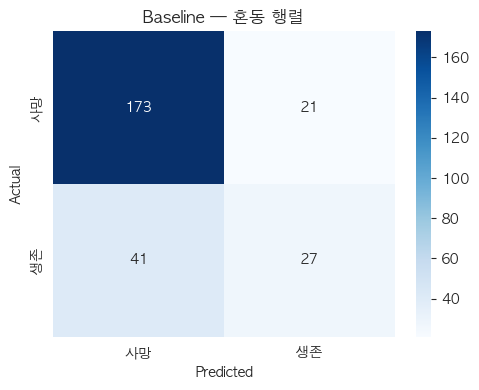

In [40]:
# 혼동 행렬
cm = confusion_matrix(y_test, pred_base)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['사망', '생존'], yticklabels=['사망', '생존'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline — 혼동 행렬')
plt.tight_layout()
plt.show()

## 7. 모델 개선

### Dropout & BatchNormalization

**Dropout** — 매 학습 step마다 뉴런의 일정 비율을 랜덤으로 비활성화하여 **과적합 방지**
- `Dropout(0.3)` = 뉴런의 30%를 랜덤으로 끔
- 학습 시에만 동작, 예측 시에는 모든 뉴런 활성화
- 비유: 노트의 30% 페이지를 가리고 공부 → 핵심 원리를 이해하게 됨

**BatchNormalization** — 층 사이 출력값을 정규화하여 **학습 안정화**
- Dense의 raw 출력 → 평균=0, 분산=1로 정규화 → Activation
- 비유: 릴레이 요리에서 매 단계마다 간을 표준으로 맞춤

배치 순서: `Dense → BatchNorm → Activation → Dropout`

### ReduceLROnPlateau
val_loss가 patience epoch 동안 개선 안 되면 **learning rate를 자동 감소**
- `factor=0.5` → lr을 절반으로
- `patience=7` → 7 epoch 정체 시 감소
- ReduceLR patience < EarlyStopping patience 여야 함

### 개선 포인트
| 항목 | Baseline | Improved |
|------|---------|----------|
| 구조 | 32 → 16 | 32 → 16 (동일, 소규모 데이터) |
| BatchNormalization | 없음 | **추가** |
| Dropout | 없음 | **0.3** |
| L2 규제 | 없음 | **l2(1e-3)** |
| EarlyStopping | 없음 | **patience=20** |
| ReduceLROnPlateau | 없음 | **patience=7** |

### 왜 모델을 키우지 않는가
1,309건은 DL 기준으로 **매우 적습니다**.
Pima(768건)에서 경험했듯이, 모델을 키우면 오히려 과적합이 발생합니다.
구조는 Baseline과 동일하게 두고 **학습 안정화 기법**만 추가합니다.

In [41]:
from tensorflow.keras import callbacks, optimizers, regularizers

tf.random.set_seed(42)
np.random.seed(42)

l2 = regularizers.l2(1e-3)

improved = Sequential([
  layers.Dense(32, input_shape=(input_dim,), kernel_regularizer=l2),
  layers.BatchNormalization(),
  layers.Activation('relu'),
  layers.Dropout(0.3),

  layers.Dense(16, activation='relu', kernel_regularizer=l2),
  layers.Dense(1, activation='sigmoid')
])

improved.compile(
  optimizer=optimizers.Adam(learning_rate=1e-3),
  loss='binary_crossentropy',
  metrics=['accuracy']
)
improved.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 32)                224       
                                                                 
 batch_normalization_1 (Bat  (None, 32)                128       
 chNormalization)                                                
                                                                 
 activation_1 (Activation)   (None, 32)                0         
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_10 (Dense)            (None, 16)                528       
                                                                 
 dense_11 (Dense)            (None, 1)                 17        
                                                      

In [42]:
early_stop = callbacks.EarlyStopping(
  monitor='val_loss', patience=20, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
  monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5
)

history_imp = improved.fit(
  X_train_s, y_train,
  validation_split=0.2,
  epochs=300,
  batch_size=32,
  callbacks=[early_stop, reduce_lr],
  verbose=0
)
print(f'학습 완료 (epoch={len(history_imp.history["loss"])})')

학습 완료 (epoch=99)


## 8. 개선 결과 비교

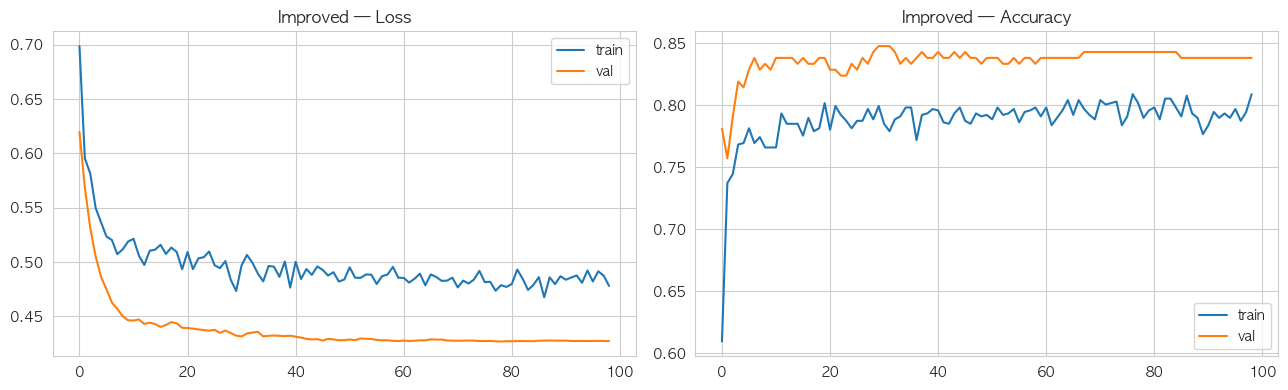

In [43]:
plot_history(history_imp, 'Improved')

In [44]:
pred_imp, prob_imp = evaluate_clf('Improved', improved, X_test_s, y_test)

=== [Improved] ===
  Accuracy  : 0.7557
  Precision : 0.5417
  Recall    : 0.3824
  F1        : 0.4483
  AUC       : 0.7663


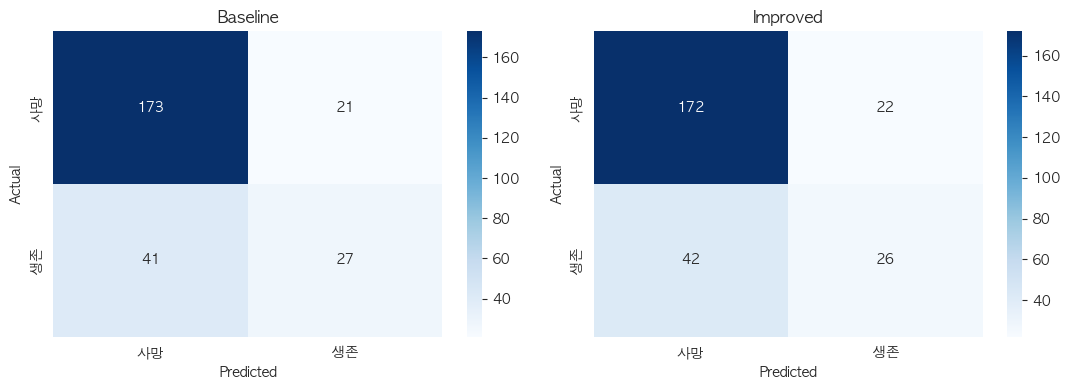

In [45]:
# 두 모델 혼동 행렬 비교
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, name, pred in zip(axes, ['Baseline', 'Improved'], [pred_base, pred_imp]):
  cm = confusion_matrix(y_test, pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
              xticklabels=['사망', '생존'], yticklabels=['사망', '생존'])
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Actual')
  ax.set_title(name)

plt.tight_layout()
plt.show()

=== DL 모델 비교 ===
          Accuracy  Precision  Recall      F1     AUC
Baseline    0.7634     0.5625  0.3971  0.4655  0.7972
Improved    0.7557     0.5417  0.3824  0.4483  0.7663


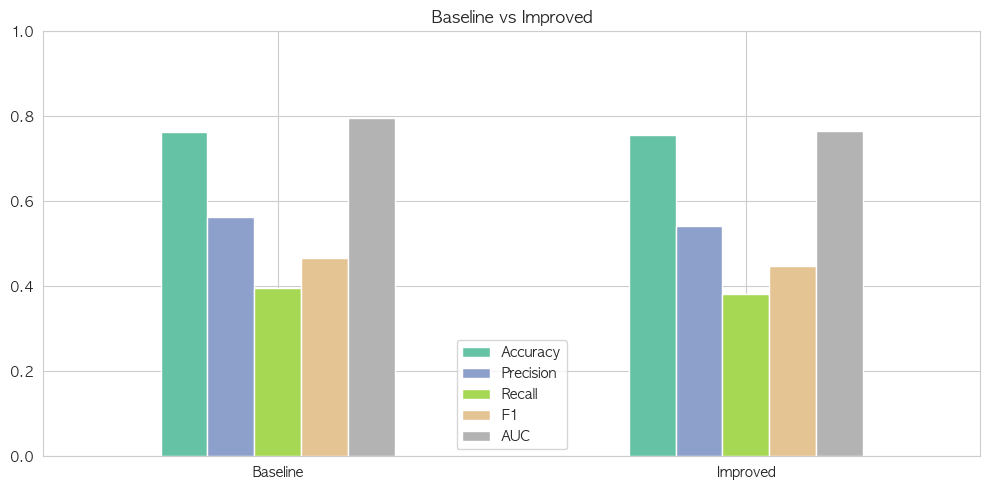

In [46]:
# 지표 비교 표
result_df = pd.DataFrame(results).T
print('=== DL 모델 비교 ===')
print(result_df.round(4))

ax = result_df.plot(kind='bar', figsize=(10, 5), colormap='Set2')
ax.set_title('Baseline vs Improved')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

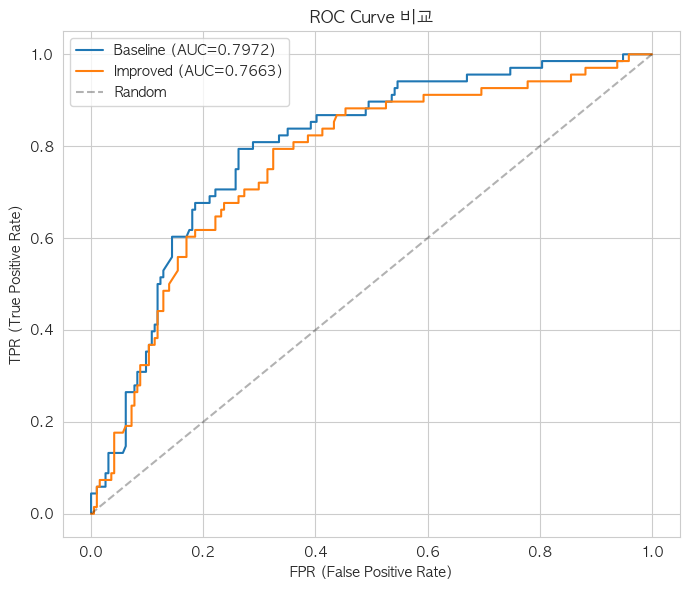

In [47]:
# ROC Curve 비교
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, prob in [('Baseline', prob_base), ('Improved', prob_imp)]:
  fpr, tpr, _ = roc_curve(y_test, prob)
  auc = roc_auc_score(y_test, prob)
  plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('ROC Curve 비교')
plt.legend()
plt.tight_layout()
plt.show()

## 9. sklearn 모델과 비교

1,309건 소규모 tabular 데이터에서는 **sklearn 모델이 DL과 비슷하거나 더 나은** 성능을 보이는 것이 일반적입니다.

=== 전체 모델 비교 ===
                    Accuracy  Precision  Recall      F1     AUC
Baseline              0.7634     0.5625  0.3971  0.4655  0.7972
Improved              0.7557     0.5417  0.3824  0.4483  0.7663
LogisticRegression    0.7481     0.5208  0.3676  0.4310  0.7594
RandomForest          0.7481     0.5156  0.4853  0.5000  0.7992
GradientBoosting      0.7290     0.4717  0.3676  0.4132  0.7901


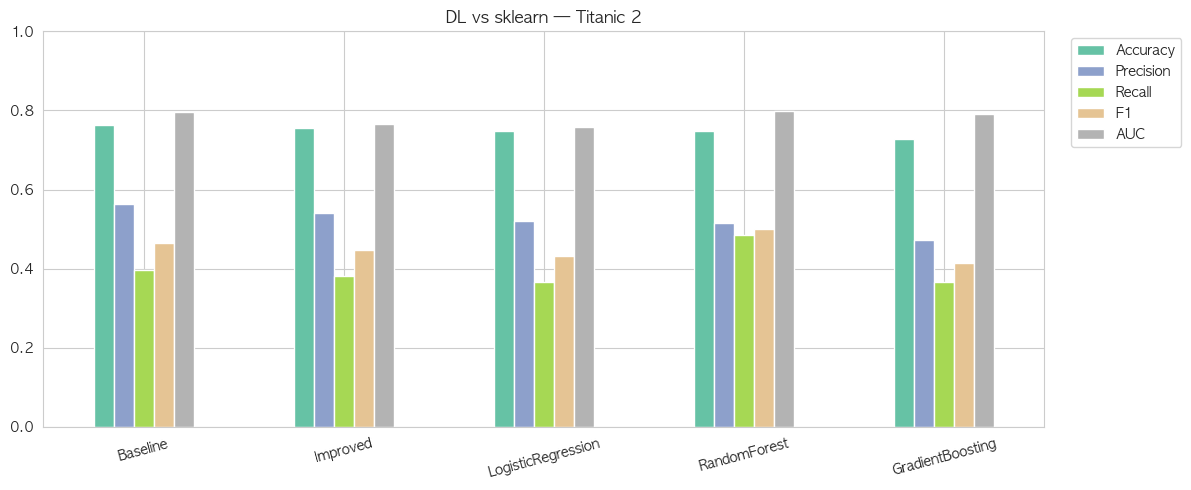

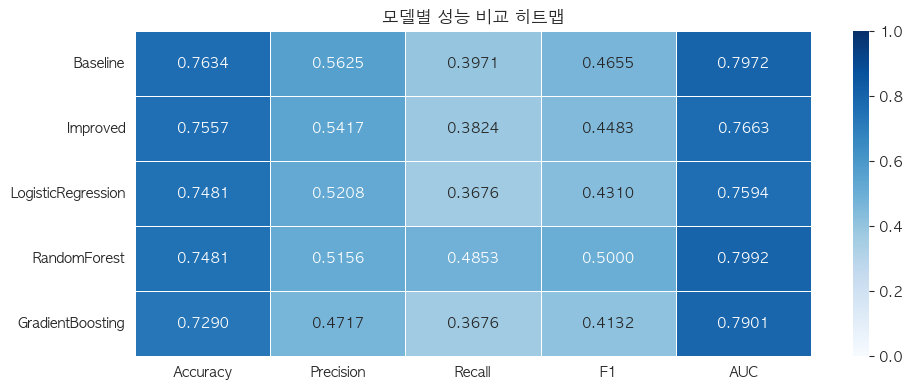

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sk_models = {
  'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
  'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
  'GradientBoosting': GradientBoostingClassifier(random_state=42),
}

for name, m in sk_models.items():
  m.fit(X_train_s, y_train)
  prob = m.predict_proba(X_test_s)[:, 1]
  pred = (prob >= 0.5).astype(int)
  results[name] = {
    'Accuracy':  accuracy_score(y_test, pred),
    'Precision': precision_score(y_test, pred),
    'Recall':    recall_score(y_test, pred),
    'F1':        f1_score(y_test, pred),
    'AUC':       roc_auc_score(y_test, prob),
  }

result_df = pd.DataFrame(results).T.round(4)
print('=== 전체 모델 비교 ===')
print(result_df)

# 막대 그래프
ax = result_df.plot(kind='bar', figsize=(12, 5), colormap='Set2')
ax.set_title('DL vs sklearn — Titanic 2')
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 히트맵 — 값이 높을수록 진한 색
plt.figure(figsize=(10, 4))
sns.heatmap(result_df, annot=True, fmt='.4f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('모델별 성능 비교 히트맵')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 정리

### Titanic 2 데이터의 핵심 포인트
- 기존 Titanic(891건)보다 **확장된 데이터** (1,309건)
- **라벨 인코딩이 이미 적용**됨 → `get_dummies` 불필요
- 컬럼명 오타 주의: `2urvived` (Survived)
- Embarked에 결측 2건 → 최빈값 대체
- 클래스 불균형: 사망 74% / 생존 26%

### 회귀 vs 분류 — 스케일링 차이
| | 회귀 (ex04_dl3) | 분류 (이 노트북) |
|---|---|---|
| X 스케일링 | StandardScaler | StandardScaler |
| **y 스케일링** | **필요** (StandardScaler/log1p) | **불필요** (0/1 라벨) |
| 출력층 | Dense(1) — linear | Dense(1, **sigmoid**) |
| Loss | MSE | **binary_crossentropy** |
| 복원 | inverse_transform / expm1 | 불필요 |

### 소규모 데이터에서 DL 개선 전략
- 모델을 키우지 **않는다** (과적합 방지)
- Baseline과 **동일 구조** + BatchNorm + Dropout + L2 규제
- EarlyStopping + ReduceLROnPlateau로 학습 안정화

### 시험에서는 이렇게 나온다
- "이진 분류의 출력층 activation은?" → **sigmoid**
- "이진 분류의 loss 함수는?" → **binary_crossentropy**
- "분류에서 y를 스케일링하지 않는 이유는?" → y가 0/1 라벨이고 sigmoid 출력이 이미 0~1
- "라벨 인코딩된 데이터에 get_dummies를 적용하면?" → 불필요한 컬럼 증가, 이미 수치이므로 그대로 사용
- "stratify=y는 무엇인가?" → 불균형 클래스 비율을 train/test에 동일하게 유지